# Backtesting Strategy

We will be using a rolling window of 20 days to trade calculate Johansen cointegration vectors (weights) and execute trades when the ratio between assets that historically cointegrated exceed 2 standard deviations. We will exit positions whenever ratios return back to mean.

<h3 style="color: tan;">Import Essential Libraries</h3>

In [ ]:
import yfinance as yf
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen


<h3 style="color: tan;">Define Functions</h3>

In [17]:
def merge_lists(data, start_date, end_date): #merges the price series of the two assets
    time_series = yf.download(data, start=start_date, end=end_date, auto_adjust=True)[
        "Close"
    ].dropna()
    return time_series

def calculate_ratios(pair_prices): #calculates time series of price ratios between the 2 assets
    if pair_prices.shape[1] != 2:
        raise ValueError("Ratio calculation requires exactly two assets.")
    ratio = pair_prices.iloc[:, 0] / pair_prices.iloc[:, 1]
    return ratio

def calculate_bollinger_bands(pair_prices, lookback_window, num_std): #using a specified lookback window, computes bollinger bands of 2 standard deviations
    ratios = calculate_ratios(pair_prices)
    means = ratios.rolling(lookback_window).mean()
    stds = ratios.rolling(lookback_window).std()
    upper_band = means + num_std * stds
    lower_band = means - num_std * stds

    return pd.DataFrame(
        {
            "ratio": ratios,
            "mean": means,
            "std": stds,
            "upper_band": upper_band,
            "lower_band": lower_band,
        }
    )

def generate_signals(data): #generates buy, sell, and exit positions within the plot
    holding_state = "None"

    data["long_signal"] = False
    data["short_signal"] = False
    data["exit_signal"] = False

    for i in range(len(data)):
        ratio = data["ratio"].iloc[i]
        upper = data["upper_band"].iloc[i]
        lower = data["lower_band"].iloc[i]
        mean = data["mean"].iloc[i]

        if holding_state == "None":
            if ratio < lower:
                data.loc[data.index[i], "long_signal"] = True
                holding_state = "Long"
            elif ratio > upper:
                data.loc[data.index[i], "short_signal"] = True
                holding_state = "Short"

        elif holding_state == "Long":
            if ratio >= mean:
                data.loc[data.index[i], "exit_signal"] = True
                holding_state = "None"

        elif holding_state == "Short":
            if ratio <= mean:
                data.loc[data.index[i], "exit_signal"] = True
                holding_state = "None"
    return data

def plot_bollinger_bands_ratio(data): #plot the graph with the bollinger bands
    plt.figure(figsize=(12, 6))

    # Plot ratio and Bollinger Bands
    plt.plot(data["ratio"], label="Ratio", color="blue", linewidth=1.2)
    plt.plot(data["mean"], label="Mean", color="black", linewidth=1.1)
    plt.plot(data["upper_band"], "--", label="Upper Band", color="red", alpha=0.7)
    plt.plot(data["lower_band"], "--", label="Lower Band", color="green", alpha=0.7)

    # Long entry points
    plt.scatter(
        data.index[data["long_signal"]],
        data["ratio"][data["long_signal"]],
        color="green",
        label="Long Entry",
        marker="^",
        s=100,
        alpha=0.8,
    )

    # Short entry points
    plt.scatter(
        data.index[data["short_signal"]],
        data["ratio"][data["short_signal"]],
        color="red",
        label="Short Entry",
        marker="v",
        s=100,
        alpha=0.8,
    )

    # Exit points (optional)
    plt.scatter(
        data.index[data["exit_signal"]],
        data["ratio"][data["exit_signal"]],
        color="orange",
        label="Exit",
        marker="x",
        s=80,
        alpha=0.8,
    )

    plt.title("Ratio-Based Bollinger Bands with Entry/Exit Signals")
    plt.xlabel("Date")
    plt.ylabel("Price Ratio")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

<h3 style="color: tan;">Assign Parameters and Variables</h3>

In [18]:
start_date = "2023-10-01"
end_date = "2024-10-01"
asset_pairs = ['GLD', 'SLV']

In [19]:
merged_data = merge_lists(asset_pairs, start_date, end_date)
bolligner_band_ratios = calculate_bollinger_bands(merged_data, 20, 2)
bollinger_band_with_signals = generate_signals(bolligner_band_ratios)
print(bollinger_band_with_signals)

[*********************100%***********************]  2 of 2 completed

               ratio      mean       std  upper_band  lower_band  long_signal  \
Date                                                                            
2023-10-02  8.735839       NaN       NaN         NaN         NaN        False   
2023-10-03  8.701646       NaN       NaN         NaN         NaN        False   
2023-10-04  8.759192       NaN       NaN         NaN         NaN        False   
2023-10-05  8.770390       NaN       NaN         NaN         NaN        False   
2023-10-06  8.601115       NaN       NaN         NaN         NaN        False   
...              ...       ...       ...         ...         ...          ...   
2024-09-24  8.375426  8.714691  0.206876    9.128443    8.300939        False   
2024-09-25  8.455953  8.710972  0.210992    9.132956    8.288987        False   
2024-09-26  8.440875  8.698864  0.219458    9.137781    8.259948        False   
2024-09-27  8.489951  8.688916  0.224387    9.137690    8.240141        False   
2024-09-30  8.555438  8.6778

<h3 style="color: tan;">Plotting the Ratios with Bollinger Bands and Entry/Exit Signals</h3>

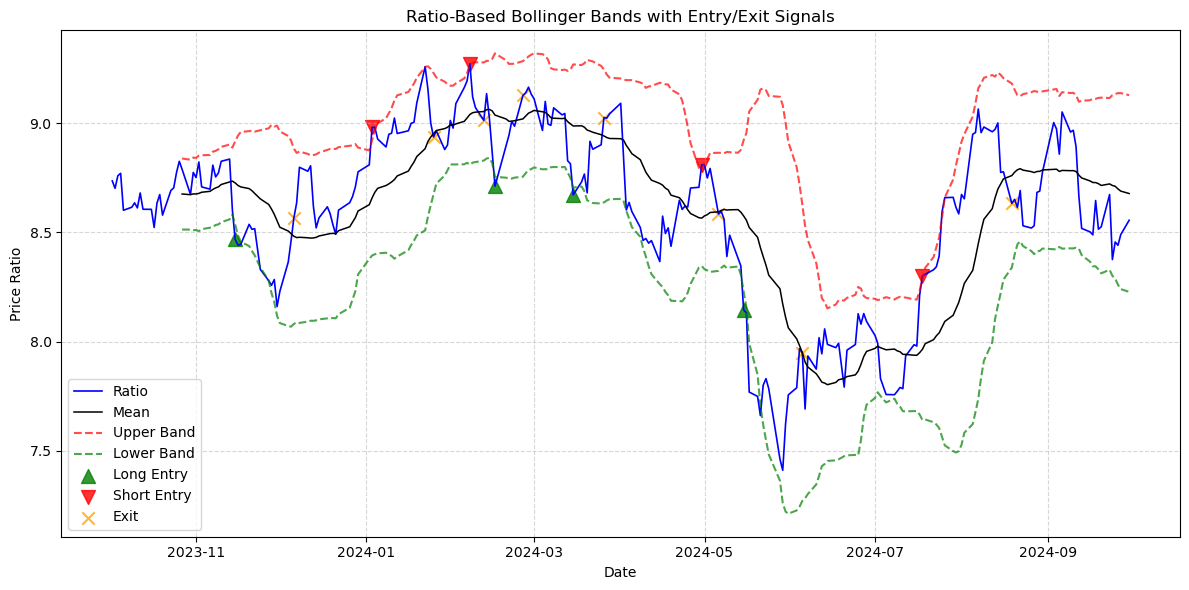

In [20]:
plot_bollinger_bands_ratio(bolligner_band_ratios)